# Model Results Story (Concise)

This notebook is the simplified daily read for model performance and improvement priorities.
Run top-to-bottom.

## 1) Setup + Data Sources

In [1]:
from pathlib import Path
import sys
import polars as pl
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists() and (candidate / "production").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(f"Cannot find repo root from cwd={Path.cwd()}")

sys.path.insert(0, str(ROOT / "src"))

DECOMP_PATH = ROOT / "artifacts" / "odds_log" / "k_error_decomposition.parquet"
DECOMP_DAILY_PATH = ROOT / "artifacts" / "odds_log" / "k_error_decomposition_daily.parquet"
SCORECARD_PATH = ROOT / "artifacts" / "odds_log" / "model_health_scorecard_daily.parquet"

print(f"decomp exists: {DECOMP_PATH.exists()}")
print(f"decomp daily exists: {DECOMP_DAILY_PATH.exists()}")
print(f"scorecard daily exists: {SCORECARD_PATH.exists()}")

decomp exists: True
decomp daily exists: True
scorecard daily exists: True


## 2) Executive Snapshot (What is broken now?)

In [2]:
if not DECOMP_PATH.exists():
    print("Missing decomposition artifact. Run production/notebooks/results_dashboard.ipynb section 11c first.")
else:
    d = pl.read_parquet(DECOMP_PATH)
    n = d.height
    mae_full = float(d.select(pl.col("err_full").abs().mean()).item())
    mae_kr = float(d.select(pl.col("err_k_rate").abs().mean()).item())
    bias_tbf_under = (
        float(d.filter(pl.col("side") == "under").select(pl.col("err_tbf").mean()).item())
        if d.filter(pl.col("side") == "under").height else float("nan")
    )
    n_dates = (
        int(d.select(pl.col("game_date").cast(pl.Utf8).str.slice(0, 10).n_unique()).item())
        if "game_date" in d.columns else 0
    )
    chrono_min_dates = 15
    print(f"n={n}")
    print(f"MAE(actual_K full error): {mae_full:.3f}")
    print(f"MAE(k_rate residual): {mae_kr:.4f}")
    print(f"Under-side TBF bias (projected_tbf - actual_PA): {bias_tbf_under:.3f}")
    print(
        "Chrono recalibration readiness: "
        f"{n_dates}/{chrono_min_dates} dates "
        f"(remaining={max(0, chrono_min_dates - n_dates)})"
    )


n=234
MAE(actual_K full error): 1.881
MAE(k_rate residual): 0.0808
Under-side TBF bias (projected_tbf - actual_PA): -1.532
Chrono recalibration readiness: 10/24 dates (remaining=14)


## 3) Where Error Concentrates (Matchup + Rest)

In [3]:
if not DECOMP_PATH.exists():
    print("Missing decomposition artifact.")
else:
    d = pl.read_parquet(DECOMP_PATH)
    if "opp_lineup_k_vs_hand" in d.columns:
        d = d.with_columns(
            pl.col("opp_lineup_k_vs_hand")
            .qcut(3, labels=["weak_matchup", "avg_matchup", "favorable_matchup"], allow_duplicates=True)
            .alias("matchup_tier")
        )
        tier = d.group_by("matchup_tier").agg(
            pl.len().alias("n"),
            pl.col("err_k_rate").abs().mean().round(4).alias("mae_err_k_rate"),
            pl.col("err_tbf").mean().round(3).alias("bias_tbf"),
            pl.col("err_full").abs().mean().round(3).alias("mae_full_k"),
        ).sort("mae_full_k", descending=True)
        print("--- by matchup tier ---")
        print(tier)

    if "days_rest" in d.columns:
        d = d.with_columns(
            pl.when(pl.col("days_rest").is_null()).then(pl.lit("unknown"))
            .when(pl.col("days_rest") <= 4).then(pl.lit("short_0_4"))
            .when(pl.col("days_rest") <= 6).then(pl.lit("normal_5_6"))
            .when(pl.col("days_rest") <= 9).then(pl.lit("extended_7_9"))
            .otherwise(pl.lit("long_10_plus"))
            .alias("days_rest_bucket")
        )
        rest = d.group_by("days_rest_bucket").agg(
            pl.len().alias("n"),
            pl.col("err_k_rate").abs().mean().round(4).alias("mae_err_k_rate"),
            pl.col("err_tbf").mean().round(3).alias("bias_tbf"),
        ).sort("mae_err_k_rate", descending=True)
        print("\n--- by days rest bucket ---")
        print(rest)


## 4) Daily Health Trend (Are we improving?)

shape: (2, 8)
┌─────────────┬────────────┬──────────┬────────────┬────────────┬────────────┬────────────┬────────┐
│ snapshot_ut ┆ ledger_sha ┆ n_joined ┆ mae_err_k_ ┆ under_bias ┆ worst_tier ┆ long_rest_ ┆ n_warn │
│ c           ┆ 256        ┆ ---      ┆ rate       ┆ _tbf       ┆ _mae_err_k ┆ bias_tbf   ┆ ---    │
│ ---         ┆ ---        ┆ i64      ┆ ---        ┆ ---        ┆ _rate      ┆ ---        ┆ i64    │
│ str         ┆ str        ┆          ┆ f64        ┆ f64        ┆ ---        ┆ f64        ┆        │
│             ┆            ┆          ┆            ┆            ┆ f64        ┆            ┆        │
╞═════════════╪════════════╪══════════╪════════════╪════════════╪════════════╪════════════╪════════╡
│ 2026-08-07T ┆ 0d47b0ba40 ┆ 117      ┆ 0.073447   ┆ -2.516463  ┆ null       ┆ null       ┆ 3      │
│ 17:54:23.63 ┆ b36ba73478 ┆          ┆            ┆            ┆            ┆            ┆        │
│ 6635+00:…   ┆ 69525c8d85 ┆          ┆            ┆            ┆            

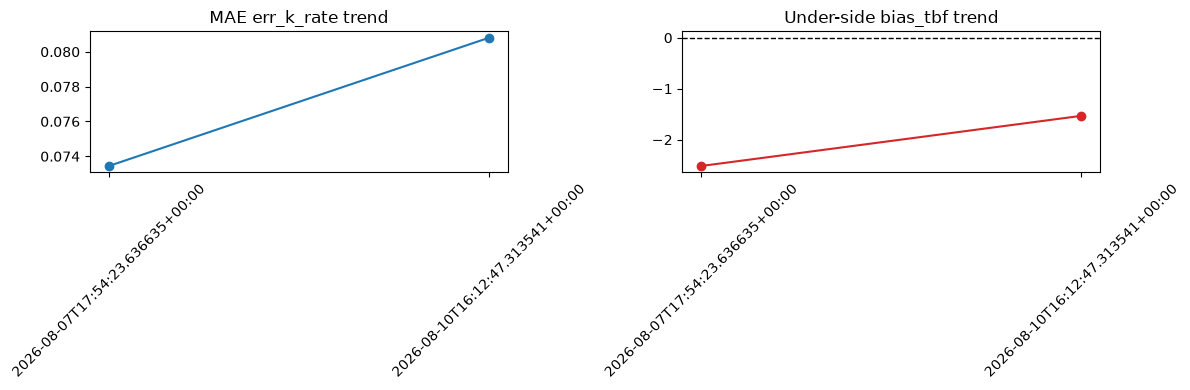

In [4]:
if not SCORECARD_PATH.exists():
    print("Missing scorecard daily artifact. Run production/notebooks/results_dashboard.ipynb section 11f first.")
else:
    s = pl.read_parquet(SCORECARD_PATH).sort("snapshot_utc")
    print(s.tail(10))

    if s.height >= 2:
        pdf = s.select("snapshot_utc", "mae_err_k_rate", "under_bias_tbf", "n_warn").to_pandas()
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        ax[0].plot(pdf["snapshot_utc"], pdf["mae_err_k_rate"], marker="o")
        ax[0].set_title("MAE err_k_rate trend")
        ax[0].tick_params(axis="x", rotation=45)

        ax[1].plot(pdf["snapshot_utc"], pdf["under_bias_tbf"], marker="o", color="tab:red")
        ax[1].axhline(0, linestyle="--", linewidth=1, color="black")
        ax[1].set_title("Under-side bias_tbf trend")
        ax[1].tick_params(axis="x", rotation=45)
        plt.tight_layout(); plt.show()


## 5) Action Queue (What to do next)

- If `mae_err_k_rate` worsens: prioritize k-rate feature/debug work.
- If under-side `bias_tbf` remains negative and large: prioritize workload/TBF underestimation fixes.
- If worst tier remains `avg_matchup` or `favorable_matchup`: focus matchup-feature interactions first.
- When at least **15 distinct dates** accumulate: run chrono recalibration winner selection (raw vs isotonic vs Platt-style) in the deep-dive notebook.